# Convert a TensorFlow Model to OpenVINO™

This short tutorial shows how to convert a TensorFlow [MobileNetV3](https://github.com/openvinotoolkit/open_model_zoo/blob/master/models/public/mobilenet-v3-small-1.0-224-tf/README.md) image classification model to OpenVINO [Intermediate Representation](https://docs.openvino.ai/2024/documentation/openvino-ir-format/operation-sets.html) (OpenVINO IR) format, using [Model Conversion API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html). After creating the OpenVINO IR, load the model in [OpenVINO Runtime](https://docs.openvino.ai/2024/openvino-workflow/running-inference.html) and do inference with a sample image.  


#### Table of contents:

- [Imports](#Imports)
- [Settings](#Settings)
- [Download model](#Download-model)
- [Convert a Model to OpenVINO IR Format](#Convert-a-Model-to-OpenVINO-IR-Format)
    - [Convert a TensorFlow Model to OpenVINO IR Format](#Convert-a-TensorFlow-Model-to-OpenVINO-IR-Format)
- [Test Inference on the Converted Model](#Test-Inference-on-the-Converted-Model)
    - [Load the Model](#Load-the-Model)
- [Select inference device](#Select-inference-device)
    - [Get Model Information](#Get-Model-Information)
    - [Load an Image](#Load-an-Image)
    - [Do Inference](#Do-Inference)
- [Timing](#Timing)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/tensorflow-classification-to-openvino/tensorflow-classification-to-openvino.ipynb" />


In [1]:
# Install openvino package
%pip install -q "openvino>=2025.4.0" "opencv-python"
%pip install -q "matplotlib>=3.4"
%pip install -q "tensorflow==2.19.1" "tf_keras==2.19.0"
%pip install -q --no-deps "tensorflow_hub==0.16.1"
%pip install -q tqdm

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## Imports
[back to top ⬆️](#Table-of-contents:)


In [2]:
import os
import time
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov
import tensorflow as tf

# Fetch `notebook_utils` module
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, device_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("tensorflow-classification-to-openvino.ipynb")

2026-10-07 04:52:30.469811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791319950.477678  305638 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791319950.480268  305638 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791319950.486723  305638 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791319950.486728  305638 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791319950.486729  305638 computation_placer.cc:177] computation placer alr

## Settings
[back to top ⬆️](#Table-of-contents:)


In [3]:
# The paths of the source and converted models.
model_dir = Path("model")
model_dir.mkdir(exist_ok=True)

model_path = Path("model/v3-small_224_1.0_float")

ir_path = Path("model/v3-small_224_1.0_float.xml")

## Download model
[back to top ⬆️](#Table-of-contents:)

Load model using [tf.keras.applications api](https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV3Small) and save it to the disk.

In [4]:
model = tf.keras.applications.MobileNetV3Small()
model.save(model_path)

2026-10-07 04:52:31.308171: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


INFO:tensorflow:Assets written to: model/v3-small_224_1.0_float/assets


INFO:tensorflow:Assets written to: model/v3-small_224_1.0_float/assets


## Convert a Model to OpenVINO IR Format
[back to top ⬆️](#Table-of-contents:)

### Convert a TensorFlow Model to OpenVINO IR Format
[back to top ⬆️](#Table-of-contents:)

Use the model conversion Python API to convert the TensorFlow model to OpenVINO IR. The `ov.convert_model` function accept path to saved model directory and returns OpenVINO Model class instance which represents this model. Obtained model is ready to use and to be loaded on a device using `ov.compile_model` or can be saved on a disk using the `ov.save_model` function.
See the [tutorial](https://docs.openvino.ai/2024/openvino-workflow/model-preparation/convert-model-tensorflow.html) for more information about using model conversion API with TensorFlow models.

In [5]:
# Run model conversion API if the IR model file does not exist
if not ir_path.exists():
    print("Exporting TensorFlow model to IR... This may take a few minutes.")
    ov_model = ov.convert_model(model_path, input=[[1, 224, 224, 3]])
    ov.save_model(ov_model, ir_path)
else:
    print(f"IR model {ir_path} already exists.")

IR model model/v3-small_224_1.0_float.xml already exists.


## Test Inference on the Converted Model
[back to top ⬆️](#Table-of-contents:)


### Load the Model
[back to top ⬆️](#Table-of-contents:)


In [6]:
core = ov.Core()
model = core.read_model(ir_path)

## Select inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [7]:
device = device_widget()

In [8]:
compiled_model = core.compile_model(model=model, device_name=device.value)

### Get Model Information
[back to top ⬆️](#Table-of-contents:)


In [9]:
input_key = compiled_model.input(0)
output_key = compiled_model.output(0)
network_input_shape = input_key.shape

### Load an Image
[back to top ⬆️](#Table-of-contents:)

Load an image, resize it, and convert it to the input shape of the network.

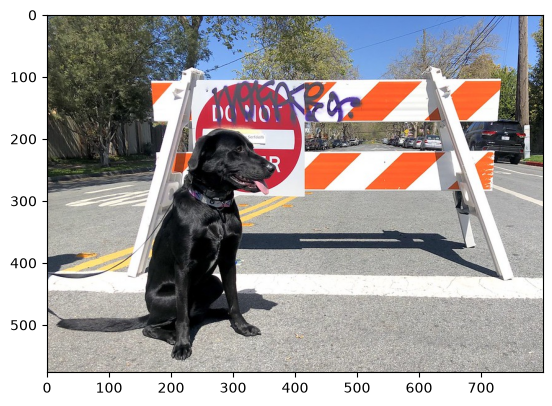

In [10]:
# Download the image from the openvino_notebooks storage
image_filename = Path("data/coco.jpg")

if not image_filename.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg",
        directory="data",
    )

# The MobileNet network expects images in RGB format.
image = cv2.cvtColor(cv2.imread(filename=str(image_filename)), code=cv2.COLOR_BGR2RGB)

# Resize the image to the network input shape.
resized_image = cv2.resize(src=image, dsize=(224, 224))

# Transpose the image to the network input shape.
input_image = np.expand_dims(resized_image, 0)

plt.imshow(image);

### Do Inference
[back to top ⬆️](#Table-of-contents:)


In [11]:
result = compiled_model(input_image)[output_key]

result_index = np.argmax(result)

In [12]:
# Download the datasets from the openvino_notebooks storage
labels_filename = Path("data/imagenet_2012.txt")
if not labels_filename.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/datasets/imagenet/imagenet_2012.txt",
        directory="data",
    )

# Convert the inference result to a class name.
imagenet_classes = labels_filename.read_text().splitlines()

imagenet_classes[result_index]

'n02099267 flat-coated retriever'

## Timing
[back to top ⬆️](#Table-of-contents:)

Measure the time it takes to do inference on thousand images. This gives an indication of performance. For more accurate benchmarking, use the [Benchmark Tool](https://docs.openvino.ai/2024/learn-openvino/openvino-samples/benchmark-tool.html) in OpenVINO. Note that many optimizations are possible to improve the performance. 

In [13]:
num_images = 1000

start = time.perf_counter()

for _ in range(num_images):
    compiled_model([input_image])

end = time.perf_counter()
time_ir = end - start

print(f"IR model in OpenVINO Runtime/CPU: {time_ir/num_images:.4f} " f"seconds per image, FPS: {num_images/time_ir:.2f}")

IR model in OpenVINO Runtime/CPU: 0.0006 seconds per image, FPS: 1658.85
